In [1]:
!pip uninstall -y datasets huggingface_hub
!pip install datasets==3.6.0 huggingface_hub==0.30.2

Found existing installation: datasets 3.6.0
Uninstalling datasets-3.6.0:
  Successfully uninstalled datasets-3.6.0
Found existing installation: huggingface_hub 1.27.0
Uninstalling huggingface_hub-1.27.0:
  Successfully uninstalled huggingface_hub-1.27.0
  Using cached datasets-3.6.0-py3-none-any.whl.metadata (19 kB)
  Using cached huggingface_hub-0.30.2-py3-none-any.whl.metadata (13 kB)
Using cached datasets-3.6.0-py3-none-any.whl (491 kB)
Using cached huggingface_hub-0.30.2-py3-none-any.whl (481 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.39.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.30.2 which is incompatible.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.30.2 which is incompatible.
transformers 5.13.1 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.30.2

In [2]:
!pip install genaibook

  Using cached huggingface_hub-1.27.0-py3-none-any.whl.metadata (16 kB)
Using cached huggingface_hub-1.27.0-py3-none-any.whl (784 kB)
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.30.2
    Uninstalling huggingface-hub-0.30.2:
      Successfully uninstalled huggingface-hub-0.30.2


In [3]:
from datasets import load_dataset

# Charger MNIST
mnist = load_dataset("mnist")

print(mnist)

Using the latest cached version of the dataset since mnist couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'mnist' at /root/.cache/huggingface/datasets/mnist/mnist/0.0.0/77f3279092a1c1579b2250db8eafed0ad422088c (last modified on Fri Aug 14 09:38:19 2026).


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})


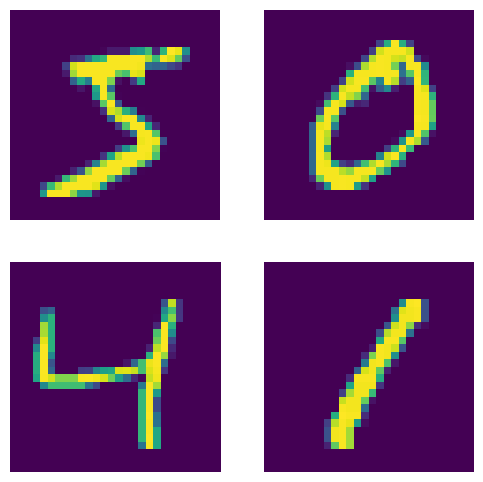

In [4]:
from genaibook.core import show_images
show_images(mnist["train"]["image"][:4])

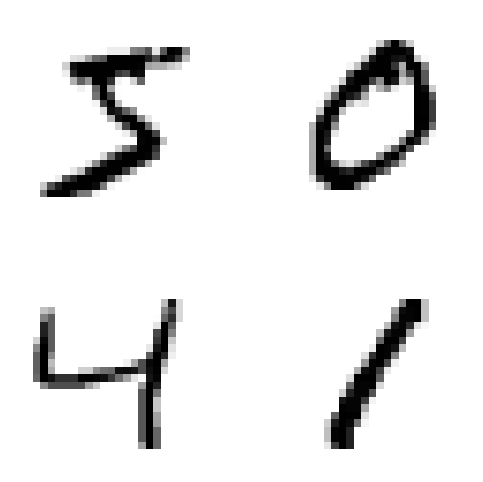

In [5]:
import matplotlib as mpl
mpl.rcParams["image.cmap"] = "gray_r"
show_images(mnist["train"]["image"][:4])

In [6]:
from torchvision import transforms
def mnist_to_tensor(samples):
 t = transforms.ToTensor()
 samples["image"] = [t(image) for image in samples["image"]]
 return samples
mnist = mnist.with_transform(mnist_to_tensor)
mnist["train"] = mnist["train"].shuffle(seed=1337)

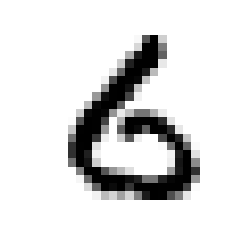

In [8]:
x = mnist["train"]["image"][0]
x.min(), x.max()
show_images(mnist["train"]["image"][0])

In [9]:
from torch.utils.data import DataLoader
bs = 64
train_dataloader = DataLoader(mnist["train"]["image"], batch_size=bs)

In [10]:
from torch import nn
def conv_block(in_channels, out_channels, kernel_size=4, stride=2, padding=1):
 return nn.Sequential(
 nn.Conv2d(
 in_channels,
 out_channels,
 kernel_size=kernel_size,
 stride=stride,
 padding=padding,
 ),
 nn.BatchNorm2d(out_channels),
 nn.ReLU(),
 )

In [11]:
class Encoder(nn.Module):
  def __init__(self, in_channels):
    super().__init__()
    self.conv1 = conv_block(in_channels, 128)
    self.conv2 = conv_block(128, 256)
    self.conv3 = conv_block(256, 512)
    self.conv4 = conv_block(512, 1024)
    self.linear = nn.Linear(1024, 16)

  def forward(self, x):
    x = self.conv1(x) # (batch size, 128, 14, 14)
    x = self.conv2(x) # (bs, 256, 7, 7)
    x = self.conv3(x) # (bs, 512, 3, 3)
    x = self.conv4(x) # (bs, 1024, 1, 1)
    # Keep batch dimension when flattening
    x = self.linear(x.flatten(start_dim=1)) # (bs, 16)
    return x

In [12]:
in_channels = 1
x = mnist["train"]["image"][0][None, :]
encoder = Encoder(in_channels).eval()
encoded = encoder(x)
encoded.shape

torch.Size([1, 16])

In [13]:
batch = next(iter(train_dataloader))
encoded = Encoder(in_channels=1)(batch)
batch.shape, encoded.shape


(torch.Size([64, 1, 28, 28]), torch.Size([64, 16]))

In [14]:
def conv_transpose_block(
 in_channels,
 out_channels,
 kernel_size=3,
 stride=2,
 padding=1,
 output_padding=0,
 with_act=True,
):
 modules = [
 nn.ConvTranspose2d(
 in_channels,
 out_channels,
 kernel_size=kernel_size,
 stride=stride,
 padding=padding,
 output_padding=output_padding,
 ),
 ]
 if with_act: # Controlling this will be handy later
  modules.append(nn.BatchNorm2d(out_channels))
 modules.append(nn.ReLU())
 return nn.Sequential(*modules)

In [15]:
class Decoder(nn.Module):
  def __init__(self, out_channels):
    super().__init__()
    self.linear = nn.Linear(
    16, 1024 * 4 * 4
    ) # note it's reshaped in forward
    self.t_conv1 = conv_transpose_block(1024, 512)
    self.t_conv2 = conv_transpose_block(512, 256, output_padding=1)
    self.t_conv3 = conv_transpose_block(256, out_channels, output_padding=1)

  def forward(self, x):
    bs = x.shape[0]
    x = self.linear(x) # (bs, 1024*4*4)
    x = x.reshape((bs, 1024, 4, 4)) # (bs, 1024, 4, 4)
    x = self.t_conv1(x) # (bs, 512, 7, 7)
    x = self.t_conv2(x) # (bs, 256, 14, 14)
    x = self.t_conv3(x) # (bs, 1, 28, 28)
    return x

In [16]:
class AutoEncoder(nn.Module):
  def __init__(self, in_channels):
    super().__init__()
    self.encoder = Encoder(in_channels)
    self.decoder = Decoder(in_channels)

  def encode(self, x):
    return self.encoder(x)

  def decode(self, x):
    return self.decoder(x)

  def forward(self, x):
    return self.decode(self.encode(x))

model = AutoEncoder(1)

In [17]:
import torchsummary
torchsummary.summary(model, input_size=(1, 28, 28), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 128, 14, 14]           2,176
       BatchNorm2d-2          [-1, 128, 14, 14]             256
              ReLU-3          [-1, 128, 14, 14]               0
            Conv2d-4            [-1, 256, 7, 7]         524,544
       BatchNorm2d-5            [-1, 256, 7, 7]             512
              ReLU-6            [-1, 256, 7, 7]               0
            Conv2d-7            [-1, 512, 3, 3]       2,097,664
       BatchNorm2d-8            [-1, 512, 3, 3]           1,024
              ReLU-9            [-1, 512, 3, 3]               0
           Conv2d-10           [-1, 1024, 1, 1]       8,389,632
      BatchNorm2d-11           [-1, 1024, 1, 1]           2,048
             ReLU-12           [-1, 1024, 1, 1]               0
           Linear-13                   [-1, 16]          16,400
          Encoder-14                   

In [18]:
import torch
from matplotlib import pyplot as plt
from torch.nn import functional as F
from tqdm.notebook import tqdm, trange
from genaibook.core import get_device

num_epochs = 10
lr = 1e-4
device = get_device()
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, eps=1e-5)
losses = [] # List to store the loss values for plotting

for _ in (progress := trange(num_epochs, desc="Training")):
  for _, batch in (
    inner := tqdm(enumerate(train_dataloader), total=len(train_dataloader))
    ):
    batch = batch.to(device)
    # Pass through the model and obtain reconstructed images
    preds = model(batch)
    # Compare the prediction with the original images
    loss = F.mse_loss(preds, batch)
    # Display loss and store for plotting
    inner.set_postfix(loss=f"{loss.cpu().item():.3f}")
    losses.append(loss.item())
    # Update the model parameters with the optimizer based on this loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
  progress.set_postfix(loss=f"{loss.cpu().item():.3f}", lr=f"{lr:.0e}")

Training:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

...

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

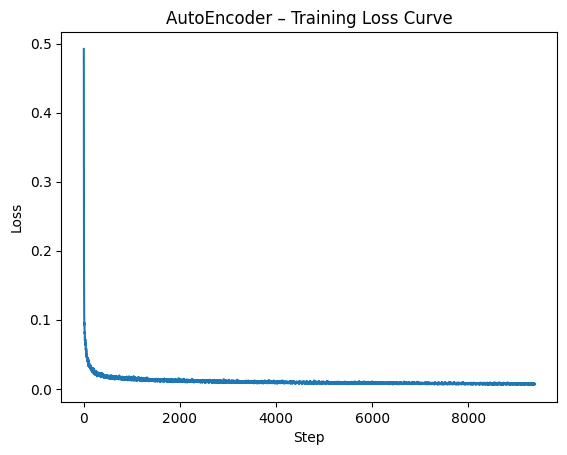

In [19]:
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("AutoEncoder – Training Loss Curve")
plt.show()

In [20]:
eval_bs = 16
eval_dataloader = DataLoader(mnist["test"]["image"], batch_size=eval_bs)

In [21]:
model.eval()
with torch.inference_mode():
 eval_batch = next(iter(eval_dataloader))
 predicted = model(eval_batch.to(device)).cpu()

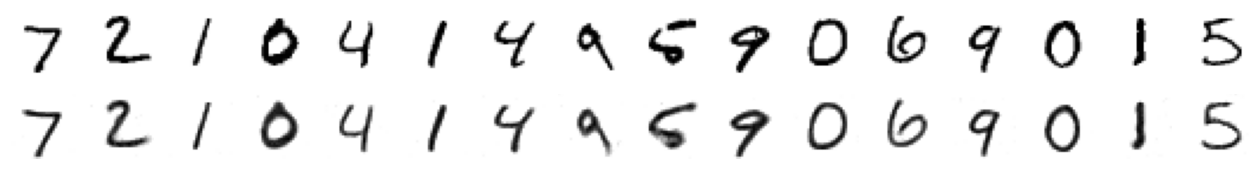

In [22]:
batch_vs_preds = torch.cat((eval_batch, predicted))
show_images(batch_vs_preds, imsize=1, nrows=2)


In [23]:
class Encoder(nn.Module):
  def __init__(self, in_channels, latent_dims):
    super().__init__()
    self.conv_layers = nn.Sequential(
    conv_block(in_channels, 128),
    conv_block(128, 256),
    conv_block(256, 512),
    conv_block(512, 1024),
    )
    self.linear = nn.Linear(1024, latent_dims)

  def forward(self, x):
    bs = x.shape[0]
    x = self.conv_layers(x)
    x = self.linear(x.reshape(bs, -1))
    return x

In [24]:
class Decoder(nn.Module):
  def __init__(self, out_channels, latent_dims):
    super().__init__()
    self.linear = nn.Linear(latent_dims, 1024 * 4 * 4)
    self.t_conv_layers = nn.Sequential(
    conv_transpose_block(1024, 512),
    conv_transpose_block(512, 256, output_padding=1),
    conv_transpose_block(
    256, out_channels, output_padding=1, with_act=False
    ),
    )
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    bs = x.shape[0]
    x = self.linear(x)
    x = x.reshape((bs, 1024, 4, 4))
    x = self.t_conv_layers(x)
    x = self.sigmoid(x)
    return x


In [25]:
class AutoEncoder(nn.Module):
  def __init__(self, in_channels, latent_dims):
    super().__init__()
    self.encoder = Encoder(in_channels, latent_dims)
    self.decoder = Decoder(in_channels, latent_dims)

  def encode(self, x):
    return self.encoder(x)

  def decode(self, x):
    return self.decoder(x)

  def forward(self, x):
    return self.decode(self.encode(x))


In [26]:
def train(model, num_epochs=10, lr=1e-4):
  optimizer = torch.optim.AdamW(model.parameters(), lr=lr, eps=1e-5)
  model.train() # Put model in training mode
  losses = []
  for _ in (progress := trange(num_epochs, desc="Training")):
    for _, batch in (
      inner := tqdm(
      enumerate(train_dataloader), total=len(train_dataloader)
      )
      ):
      batch = batch.to(device)
      # Pass through the model and obtain another set of images
      preds = model(batch)
      # Compare the prediction with the original images
      loss = F.mse_loss(preds, batch)
      # Display loss and store for plotting
      inner.set_postfix(loss=f"{loss.cpu().item():.3f}")
      losses.append(loss.item())
      # Update the model parameters with the optimizer based on this loss
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
    progress.set_postfix(loss=f"{loss.cpu().item():.3f}", lr=f"{lr:.0e}")
  return losses

Training:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

...

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

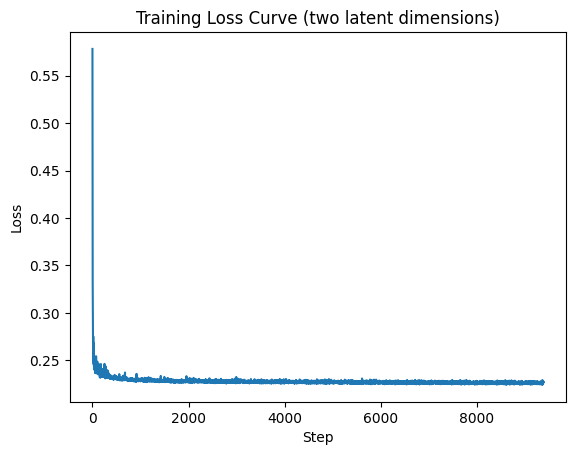

In [27]:
ae_model = AutoEncoder(in_channels=1, latent_dims=2)
ae_model.to(device)
losses = train(ae_model)
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve (two latent dimensions)")
plt.show()


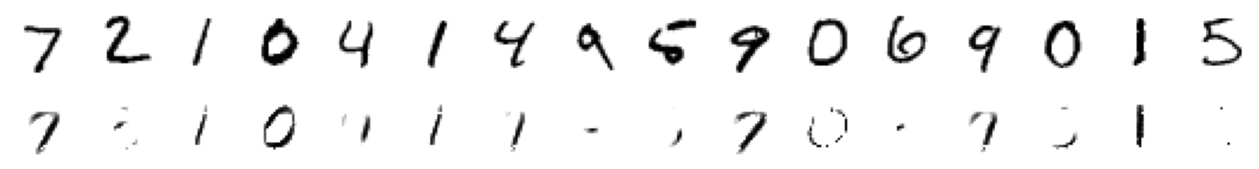

In [28]:
ae_model.eval()
with torch.inference_mode():
 eval_batch = next(iter(eval_dataloader))
 predicted = ae_model(eval_batch.to(device)).cpu()
 batch_vs_preds = torch.cat((eval_batch, predicted))
 show_images(batch_vs_preds, imsize=1, nrows=2)


  0%|          | 0/20 [00:00<?, ?it/s]

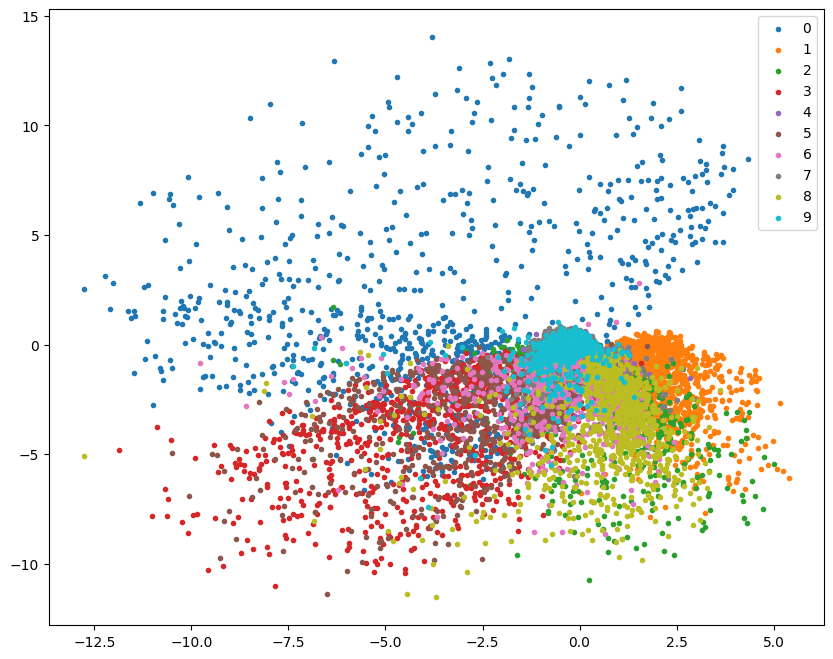

In [29]:
images_labels_dataloader = DataLoader(mnist["test"], batch_size=512)
import pandas as pd

df = pd.DataFrame(
 {
 "x": [],
 "y": [],
 "label": [],
 }
)
for batch in tqdm(
 iter(images_labels_dataloader), total=len(images_labels_dataloader)
):
 encoded = ae_model.encode(batch["image"].to(device)).cpu()
 new_items = {
 "x": [t.item() for t in encoded[:, 0]],
 "y": [t.item() for t in encoded[:, 1]],
 "label": batch["label"],
 }
 df = pd.concat([df, pd.DataFrame(new_items)], ignore_index=True)
plt.figure(figsize=(10, 8))
for label in range(10):
 points = df[df["label"] == label]
 plt.scatter(points["x"], points["y"], label=label, marker=".")
plt.legend();

In [30]:
class VAEEncoder(nn.Module):
  def __init__(self, in_channels, latent_dims):
    super().__init__()
    self.conv_layers = nn.Sequential(
    conv_block(in_channels, 128),
    conv_block(128, 256),
    conv_block(256, 512),
    conv_block(512, 1024),
    )
    # Define fully connected layers for mean and log-variance
    self.mu = nn.Linear(1024, latent_dims)
    self.logvar = nn.Linear(1024, latent_dims)

  def forward(self, x):
    bs = x.shape[0]
    x = self.conv_layers(x)
    x = x.reshape(bs, -1)
    mu = self.mu(x)
    logvar = self.logvar(x)
    return (mu, logvar)

In [34]:
class VAE(nn.Module):
 def __init__(self, in_channels, latent_dims):
  super().__init__()
  self.encoder = VAEEncoder(in_channels, latent_dims)
  self.decoder = Decoder(in_channels, latent_dims)

 def encode(self, x):
  # Returns mu, log_var
  return self.encoder(x)

 def decode(self, z):
  return self.decoder(z)

 def forward(self, x):
  # Obtain parameters of the normal (Gaussian) distribution
  mu, logvar = self.encode(x)
  # Sample from the distribution
  std = torch.exp(0.5 * logvar)
  z = self.sample(mu, std)
  # Decode the latent point to pixel space
  reconstructed = self.decode(z)
  # Return the reconstructed image, and also the mu and logvar
  # so we can compute a distribution loss
  return reconstructed, mu, logvar

 def sample(self, mu, std):
  # Reparametrization trick
  # Sample from N(0, I), translate and scale
  eps = torch.randn_like(std)
  return mu + eps * std

In [35]:
def vae_loss(batch, reconstructed, mu, logvar):
 bs = batch.shape[0]
 # Reconstruction loss from the pixels - 1 per image
 reconstruction_loss = F.mse_loss(
 reconstructed.reshape(bs, -1),
 batch.reshape(bs, -1),
 reduction="none",
 ).sum(dim=-1)
 # KL-divergence loss, per input image
 kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=-1)
 # Combine both losses and get the mean across images
 loss = (reconstruction_loss + kl_loss).mean(dim=0)
 return (loss, reconstruction_loss, kl_loss)

In [37]:
def train_vae(model, num_epochs=10, lr=1e-4):
  model = model.to(device)
  losses = {
  "loss": [],
  "reconstruction_loss": [],
  "kl_loss": [],
  }
  model.train()
  optimizer = torch.optim.AdamW(model.parameters(), lr=lr, eps=1e-5)
  for _ in (progress := trange(num_epochs, desc="Training")):
    for _, batch in (
      inner := tqdm(
      enumerate(train_dataloader), total=len(train_dataloader)
      )
      ):
      batch = batch.to(device)
      # Pass through the model
      reconstructed, mu, logvar = model(batch)
      # Compute the losses
      loss, reconstruction_loss, kl_loss = vae_loss(
      batch, reconstructed, mu, logvar
      )
      # Display loss and store for plotting
      inner.set_postfix(loss=f"{loss.cpu().item():.3f}")
      losses["loss"].append(loss.item())
      losses["reconstruction_loss"].append(
      reconstruction_loss.mean().item()
      )
      losses["kl_loss"].append(kl_loss.mean().item())
      # Update model parameters based on the total loss
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    progress.set_postfix(loss=f"{loss.cpu().item():.3f}", lr=f"{lr:.0e}")
  return losses

vae_model = VAE(in_channels=1, latent_dims=2)
losses = train_vae(vae_model, num_epochs=10, lr=1e-4)


Training:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

...

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

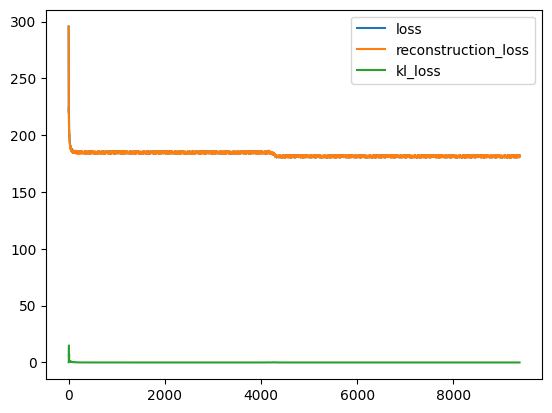

In [38]:
for k, v in losses.items():
 plt.plot(v, label=k)
plt.legend();

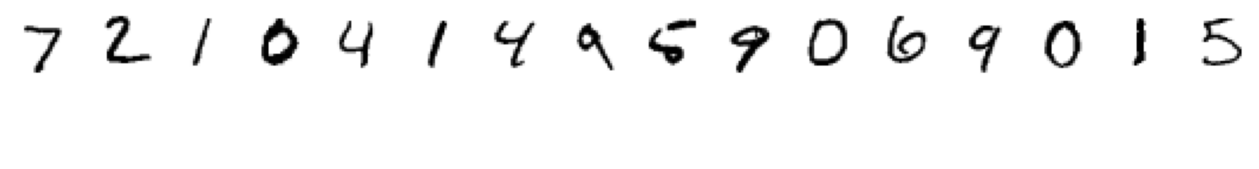

In [39]:
vae_model.eval()
with torch.inference_mode():
 eval_batch = next(iter(eval_dataloader))
 predicted, mu, logvar = (v.cpu() for v in vae_model(eval_batch.to(device)))
batch_vs_preds = torch.cat((eval_batch, predicted))
show_images(batch_vs_preds, imsize=1, nrows=2)

In [40]:
import requests
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from genaibook.core import SampleURL

clip = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
url = SampleURL.LionExample
image = Image.open(requests.get(url, stream=True).raw)

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.71GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [41]:
image_inputs = processor(images=image, return_tensors="pt")
pixel_values = image_inputs["pixel_values"]
pixel_values.shape, pixel_values.min(), pixel_values.max()

(torch.Size([1, 3, 224, 224]), tensor(-1.7923), tensor(1.9895))

In [43]:
processor.image_processor

CLIPImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "CLIPImageProcessor",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}

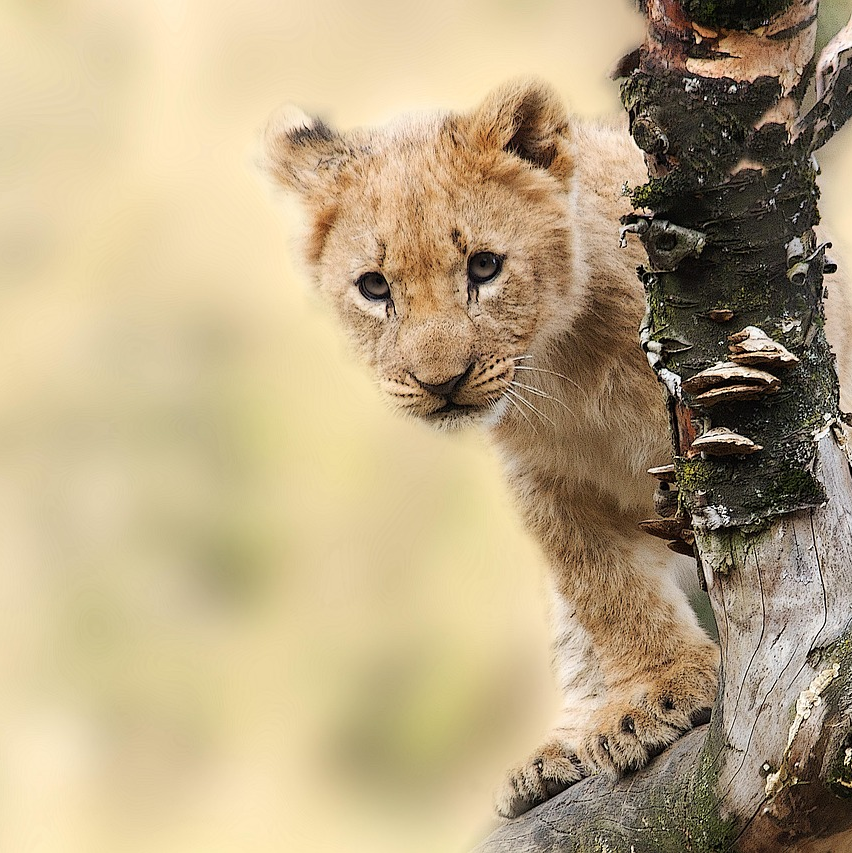

In [44]:
width, height = image.size
crop_length = min(image.size)
left = (width - crop_length) / 2
top = (height - crop_length) / 2
right = (width + crop_length) / 2
bottom = (height + crop_length) / 2
cropped = image.crop((left, top, right, bottom))
cropped

In [45]:
with torch.inference_mode():
 output = clip.vision_model(pixel_values.to(device))
image_embeddings = output.pooler_output
image_embeddings.shape

torch.Size([1, 1024])

In [46]:
prompts = [
 "a photo of a lion",
 "a photo of a zebra",
]

In [47]:
text_inputs = processor(text=prompts, return_tensors="pt", padding=True)

In [48]:
text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
with torch.inference_mode():
 text_output = clip.text_model(**text_inputs)
text_embeddings = text_output.pooler_output
text_embeddings.shape


torch.Size([2, 768])

In [50]:
print(clip.text_projection)
print(clip.visual_projection)
with torch.inference_mode():
 text_embeddings = clip.text_projection(text_embeddings)
 image_embeddings = clip.visual_projection(image_embeddings)
text_embeddings.shape, image_embeddings.shape

Linear(in_features=768, out_features=768, bias=False)
Linear(in_features=1024, out_features=768, bias=False)


(torch.Size([2, 768]), torch.Size([1, 768]))

In [51]:
text_embeddings = text_embeddings / text_embeddings.norm(
 p=2, dim=-1, keepdim=True
)
image_embeddings = image_embeddings / image_embeddings.norm(
 p=2, dim=-1, keepdim=True
)
similarities = torch.matmul(text_embeddings, image_embeddings.T)
similarities


tensor([[0.2225],
        [0.1935]], device='cuda:0')

In [52]:
similarities = 100 * torch.matmul(text_embeddings, image_embeddings.T)
similarities.softmax(dim=0).cpu()

tensor([[0.9477],
        [0.0523]])

In [53]:
clip = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
image = Image.open(requests.get(SampleURL.LionExample, stream=True).raw)

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

In [54]:
prompts = [
 "a photo of a lion",
 "a photo of a zebra",
 "a photo of a cat",
 "a photo of an adorable lion cub",
 "a puppy",
 "a lion behind a branch",
]

inputs = processor(
 text=prompts, images=image, return_tensors="pt", padding=True
)
inputs = {k: v.to(device) for k, v in inputs.items()}
outputs = clip(**inputs)
logits_per_image = outputs.logits_per_image
probabilities = logits_per_image.softmax(dim=1)
probabilities = probabilities[0].cpu().detach().tolist()
for prob, prompt in sorted(zip(probabilities, prompts), reverse=True):
 print(f"{100*prob: =2.0f}%: {prompt}")

84%: a photo of an adorable lion cub
13%: a lion behind a branch
 3%: a photo of a lion
 0%: a photo of a zebra
 0%: a photo of a cat
 0%: a puppy


In [55]:
from transformers import pipeline
classifier = pipeline(
 "zero-shot-image-classification",
 model="openai/clip-vit-large-patch14",
 device=device,
)

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

In [56]:
scores = classifier(
 image,
 candidate_labels=prompts,
 hypothesis_template="{}",
)


In [57]:
scores

[{'score': 0.8425642848014832, 'label': 'a photo of an adorable lion cub'},
 {'score': 0.1260693073272705, 'label': 'a lion behind a branch'},
 {'score': 0.029034096747636795, 'label': 'a photo of a lion'},
 {'score': 0.0016014184802770615, 'label': 'a photo of a zebra'},
 {'score': 0.0007010705885477364, 'label': 'a photo of a cat'},
 {'score': 2.9856613764422946e-05, 'label': 'a puppy'}]